In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\cognifyz internship\Dataset .csv")

In [2]:
# Split cuisines and expand rows
df_cuisine = df.copy()
df_cuisine['Cuisines'] = df_cuisine['Cuisines'].str.split(', ')
df_cuisine = df_cuisine.explode('Cuisines')

# Remove missing values
df_cuisine = df_cuisine.dropna(subset=['Cuisines'])

In [3]:
cuisine_rating = df_cuisine.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False)

print(cuisine_rating.head(10))

Cuisines
Sunda         4.900000
B�_rek        4.700000
Taiwanese     4.650000
Ramen         4.500000
Dim Sum       4.466667
Hawaiian      4.412500
Bubble Tea    4.400000
D�_ner        4.400000
Curry         4.400000
Kebab         4.380000
Name: Aggregate rating, dtype: float64


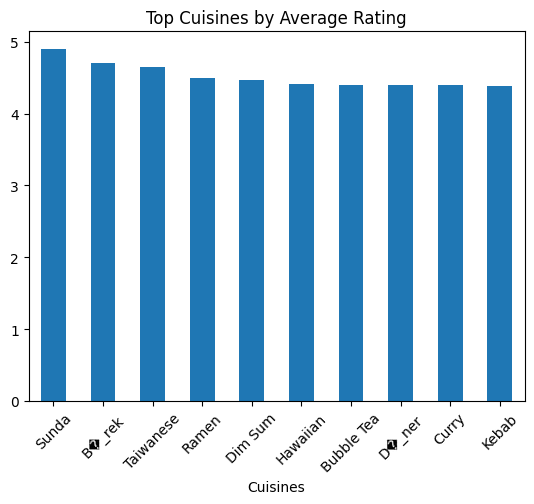

In [4]:
cuisine_rating.head(10).plot(kind='bar')
plt.title("Top Cuisines by Average Rating")
plt.xticks(rotation=45)
plt.show()

In [5]:
cuisine_votes = df_cuisine.groupby('Cuisines')['Votes'].sum().sort_values(ascending=False)

print(cuisine_votes.head(10))

Cuisines
North Indian    595981
Chinese         364351
Italian         329265
Continental     288255
Fast Food       184058
American        183117
Cafe            177568
Mughlai         151946
Desserts        105889
Asian           104303
Name: Votes, dtype: int64


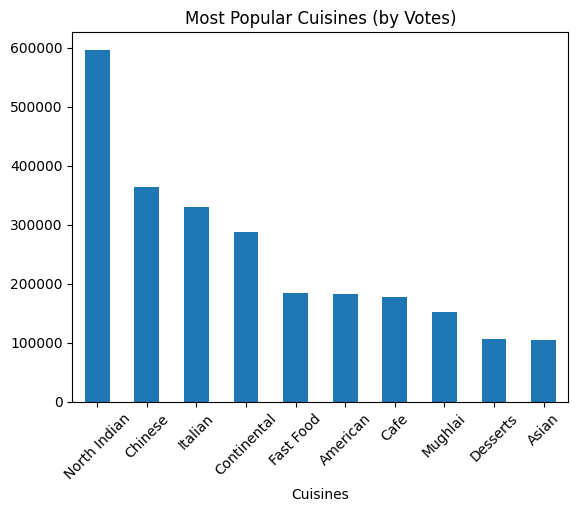

In [6]:
cuisine_votes.head(10).plot(kind='bar')
plt.title("Most Popular Cuisines (by Votes)")
plt.xticks(rotation=45)
plt.show()

In [7]:
# Filter cuisines with good ratings and enough data
high_rated = df_cuisine.groupby('Cuisines').agg({
    'Aggregate rating': 'mean',
    'Votes': 'sum'
})

# Apply condition (adjust threshold if needed)
high_rated = high_rated[
    (high_rated['Aggregate rating'] >= 4.0) &
    (high_rated['Votes'] > 1000)
].sort_values(by='Aggregate rating', ascending=False)

print(high_rated.head(10))

               Aggregate rating  Votes
Cuisines                              
Sunda                  4.900000   5514
B�_rek                 4.700000   1305
Ramen                  4.500000   1259
Dim Sum                4.466667   1755
Hawaiian               4.412500   8012
Curry                  4.400000   2059
Kebab                  4.380000   1536
Izgara                 4.350000   1166
Filipino               4.340000   3789
South African          4.333333   1806


In [8]:
correlation = df_cuisine[['Votes', 'Aggregate rating']].corr()
print(correlation)

                     Votes  Aggregate rating
Votes             1.000000          0.312963
Aggregate rating  0.312963          1.000000


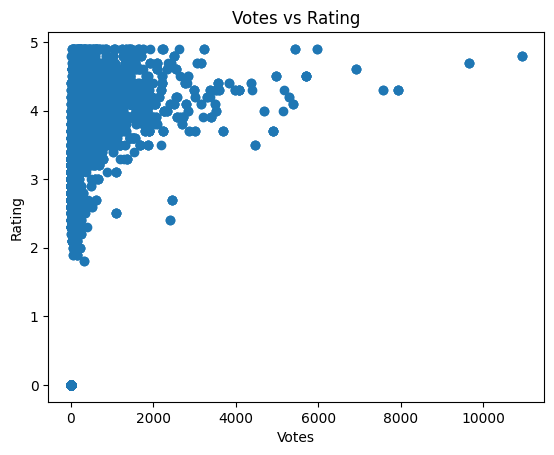

In [9]:
plt.scatter(df_cuisine['Votes'], df_cuisine['Aggregate rating'])
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.title("Votes vs Rating")
plt.show()